# БДЗ 2

In [1]:
import sys
# sys.path.append("src")

In [2]:
import torch
from torch.utils.data import DataLoader
import torchtext
from pathlib import Path
import sacrebleu

from src.dataset import TranslationDataset, collate_fn
from src.models.rnn import Seq2Seq
from src.train import train
from src.inference import translate_file
from src.prepare_spm import train_sentencepiece

In [12]:
print(f"PyTorch версия: {torch.__version__}")
print(f"torchtext версия: {torchtext.__version__}")
print(f"sacrebleu версия: {sacrebleu.__version__}")

PyTorch версия: 2.10.0
torchtext версия: 0.6.0
sacrebleu версия: 2.6.0


In [4]:
DATA_DIR = "data"
FORCE_RETRAIN_SPM = False # принудительное пересоздание модели SentencePiece
VOCAB_SIZE = 2000

SPM_MODEL_PATH = Path(DATA_DIR) / "sentencepiece.model"

if not SPM_MODEL_PATH.exists() or FORCE_RETRAIN_SPM:
    print("SentencePiece model not found. Training...")
    train_sentencepiece(
        data_dir=DATA_DIR,
        vocab_size=VOCAB_SIZE,
        model_prefix="sentencepiece"
    )
else:
    print("SentencePiece model already exists.")

SentencePiece model already exists.


In [5]:
BATCH_SIZE = 64

train_ds = TranslationDataset(
    "train.de-en.de",
    "train.de-en.en",
    "sentencepiece.model"
)

val_ds = TranslationDataset(
    "val.de-en.de",
    "val.de-en.en",
    "sentencepiece.model"
)

PAD = train_ds.PAD
vocab_size = train_ds.vocab_size + 3

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

In [6]:
# обрезка датасета для быстрого тестирования
DEBUG = True
DEBUG_SAMPLES = 2000

if DEBUG:
    train_ds.src_lines = train_ds.src_lines[:DEBUG_SAMPLES]
    train_ds.tgt_lines = train_ds.tgt_lines[:DEBUG_SAMPLES]

    val_ds.src_lines = val_ds.src_lines[:500]
    val_ds.tgt_lines = val_ds.tgt_lines[:500]

    print("Running in DEBUG mode")
    print("Train size:", len(train_ds))
    print("Val size:", len(val_ds))

Running in DEBUG mode
Train size: 2000
Val size: 500


In [ ]:
# параметры обучения

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

model = Seq2Seq(
    vocab_size,
    emb_size=64,
    hidden_size=128
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

scheduler = None

criterion = torch.nn.CrossEntropyLoss(ignore_index=PAD)

NUM_EPOCHS = 5

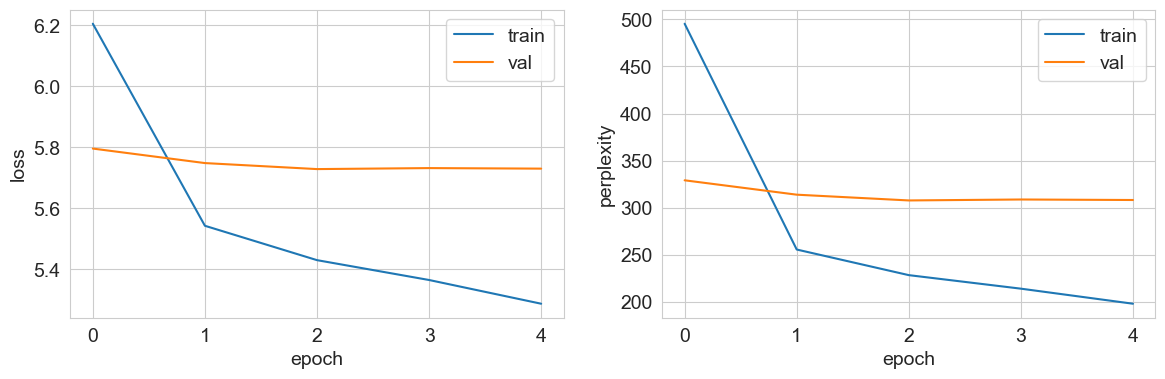

In [8]:
# обучение модели
train_losses, val_losses, train_ppls, val_ppls = train(
    model,
    optimizer,
    scheduler,
    criterion,
    train_loader,
    val_loader,
    PAD,
    num_epochs=NUM_EPOCHS,
    plot=True
)

In [9]:
# BLEU на валидации

val_src = open("data/val.de-en.de", encoding="utf-8").read().splitlines()
val_ref = open("data/val.de-en.en", encoding="utf-8").read().splitlines()

VAL_OUTPUT_PATH = "outputs/val_predictions.en"

translate_file(
    model=model,
    dataset=train_ds,
    input_lines=val_src,
    device=device,
    output_path=VAL_OUTPUT_PATH,
    max_decoding_len=50
)

val_pred = open(VAL_OUTPUT_PATH, encoding="utf-8").read().splitlines()

bleu = sacrebleu.corpus_bleu(val_pred, [val_ref])
print("Validation BLEU:", bleu.score)

That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Validation BLEU: 0.25240717320038675


In [13]:
# quick diagnostics
import re
from pprint import pprint

# загрузите предсказания и референсы (как вы делаете)
val_pred = open("outputs/val_predictions.en", encoding="utf-8").read().splitlines()
val_ref  = open("data/val.de-en.en", encoding="utf-8").read().splitlines()

print("counts: pred =", len(val_pred), "ref =", len(val_ref))

# посмотрим на первые 10 примеров в repr-форме, чтобы увидеть пробелы/токены
for i in range(10):
    print(f"\n=== Example {i} ===")
    print("PRED repr:", repr(val_pred[i]))
    print("REF  repr:", repr(val_ref[i]))

counts: pred = 986 ref = 986

=== Example 0 ===
PRED repr: "i i i i i i i 's , i 's , i 's , and i , and i , and i , and i , and i , and i , and i , and i , and i , and i , and i"
REF  repr: 'when i was 11 , i remember waking up one morning to the sound of joy in my house .'

=== Example 1 ===
PRED repr: 'and they , , , , , , , , , , , , ,s ,s ,s ,s ,s ,s ,s ,s .'
REF  repr: 'my father was listening to bbc news on his small , gray radio .'

=== Example 2 ===
PRED repr: 'and they , , they ,s ,s ,s ,s ,s ,s ,s ,sssssssssssss .s .s .s .s .'
REF  repr: 'there was a big smile on his face which was unusual then , because the news mostly depressed him .'

=== Example 3 ===
PRED repr: 'and theyss . . . . . . . . . . . . . . . . . . . . . . .'
REF  repr: '" the taliban are gone ! " my father shouted .'

=== Example 4 ===
PRED repr: "i i i i 's , i 's , i 's . . . . . . . . . . . . . . . . . ."
REF  repr: "i didn 't know what it meant , but i could see that my father was very , very happy ."

==

In [10]:
# прогноз для тестового набора

test_lines = open("data/test1.de-en.de", encoding="utf-8").read().splitlines()

OUTPUT_PATH = "outputs/test1.de-en.en"

translate_file(
    model=model,
    dataset=train_ds,
    input_lines=test_lines,
    device=device,
    output_path=OUTPUT_PATH,
    max_decoding_len=50
)

print(f"Test translations saved to {OUTPUT_PATH}")

Test translations saved to outputs/test1.de-en.en
